<a href="https://colab.research.google.com/github/ataurcsesust/Machine-Learning/blob/main/Breast__Cancer_Classification_with_NN_ipynb0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split

In [ ]:
# loading the data from sklearn
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

In [ ]:
print(breast_cancer_dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [ ]:
# loading the data to a data frame
data_frame = pd.DataFrame(breast_cancer_dataset.data, columns = breast_cancer_dataset.feature_names)

In [ ]:
# print the first 5 rows of the dataframe
data_frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# adding the 'target' column to the data frame
data_frame['label'] = breast_cancer_dataset.target

In [ ]:
# checking the distribution of Target Varibale
data_frame['label'].value_counts()

,count
label,
1,357
0,212


In [ ]:
data_frame.groupby('label').mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
label,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


In [ ]:
X = data_frame.drop(columns='label', axis=1)
Y = data_frame['label']

Splitting the data into training data & Testing data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

Standardize the data

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)

X_test_std = scaler.transform(X_test)

**Building the Neural Network** **bold text**

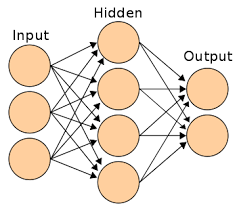

In [ ]:
# importing tensorflow and Keras
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras

TensorFlow ব্যবহার করা হয়:

Deep Learning Model তৈরি করতে

Neural Network Train করতে

GPU/TPU ব্যবহার করে দ্রুত Computation করতে

Machine Learning ও AI Applications তৈরি করতে

#############

GPU (Graphics Processing Unit) এবং TPU (Tensor Processing Unit) হলো এমন হার্ডওয়্যার যা Machine Learning ও Deep Learning-এর গণনা (Computation) অনেক দ্রুত করতে ব্যবহৃত হয়।



tf.random.set_seed(3)

এটি TensorFlow-এর Random Seed নির্ধারণ করে।

এর ফলে Random Number Generation প্রতিবার একইভাবে হবে।

এটি ব্যবহার করলে:

Model initialization একই থাকবে।

ফলাফল Reproducible হবে।

Experiment বারবার চালালেও একই Output পাওয়ার সম্ভাবনা বাড়ে (অন্যান্য randomness নিয়ন্ত্রিত থাকলে)।

প্রতিবার একই Seed ব্যবহার করলে একই Random Value পাওয়া যাবে।


Keras হলো Deep Learning Model তৈরি করার জন্য একটি উচ্চ-স্তরের (High-Level) API।

এটি ব্যবহার করে খুব সহজে:

Neural Network তৈরি   (Neural Network তৈরি বলতে বোঝায় এমন একটি AI Model তৈরি করা, যা মানুষের মস্তিষ্কের নিউরনের (Neurons) কাজ করার ধারণা অনুসরণ করে তথ্য থেকে শেখে এবং সিদ্ধান্ত নিতে পারে।)

Layer যোগ করা  (একটি Deep Learning Model মূলত অনেকগুলো Layer নিয়ে গঠিত।)

Model Compile

Model Train

Prediction

Model Save/Load

করা যায়।


Model Compile বলতে বোঝায়, Neural Network-কে Training শুরু করার জন্য প্রস্তুত করা।

Model তৈরি করার পরে (Sequential, Dense ইত্যাদি দিয়ে), TensorFlow/Keras এখনো জানে না—

কীভাবে Model-এর ভুল (Error) পরিমাপ করবে?

কোন Algorithm ব্যবহার করে Weight Update করবে?

কোন Metric দিয়ে Performance দেখাবে?

এই তথ্যগুলো model.compile()-এ দেওয়া হয়।

In [ ]:
# setting up the layers of Neural Network

model = keras.Sequential([
                          keras.layers.Flatten(input_shape=(30,)),
                          keras.layers.Dense(20, activation='relu'),
                          keras.layers.Dense(2, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


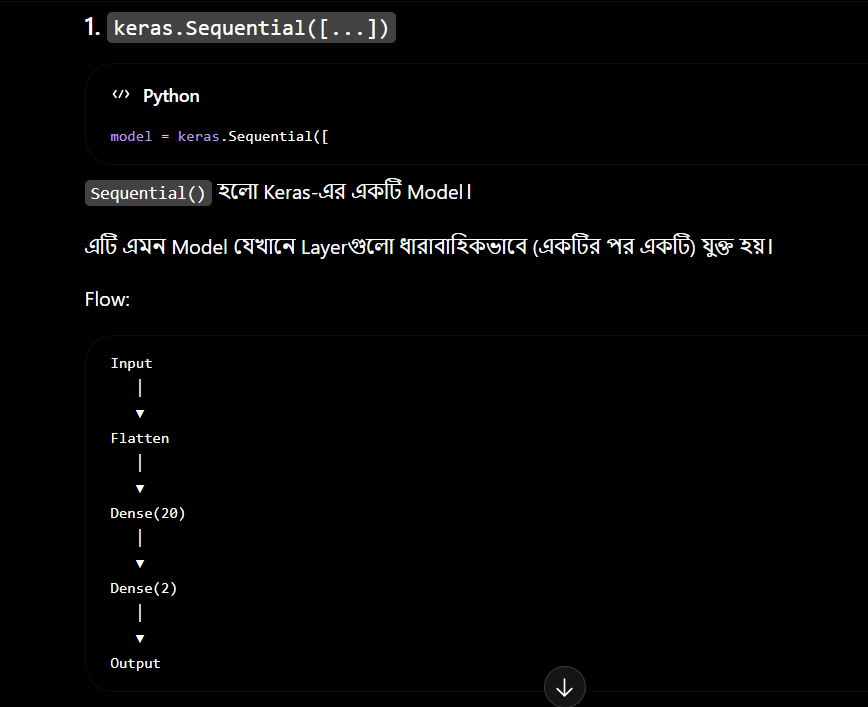

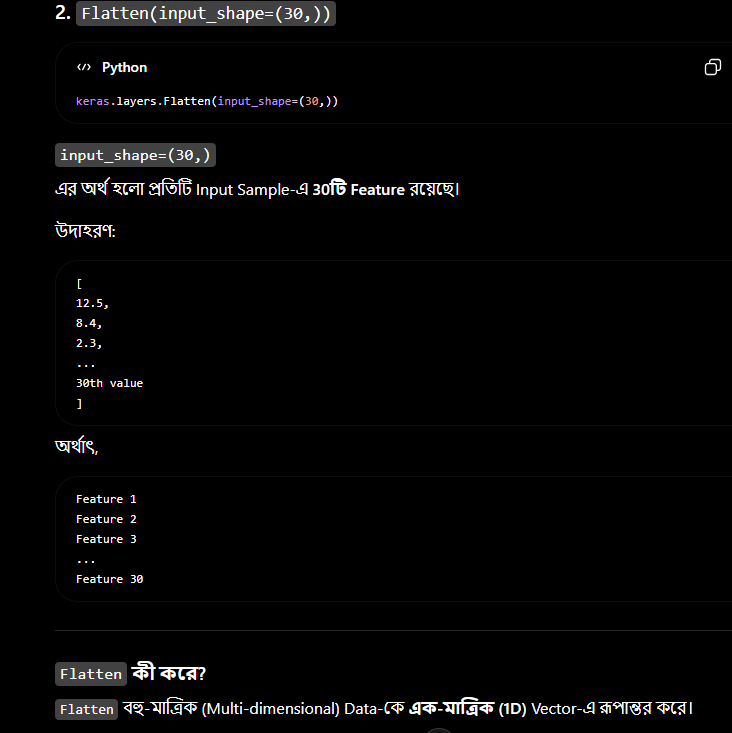

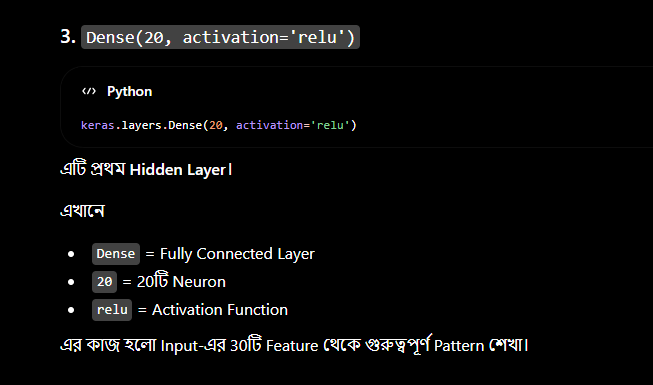

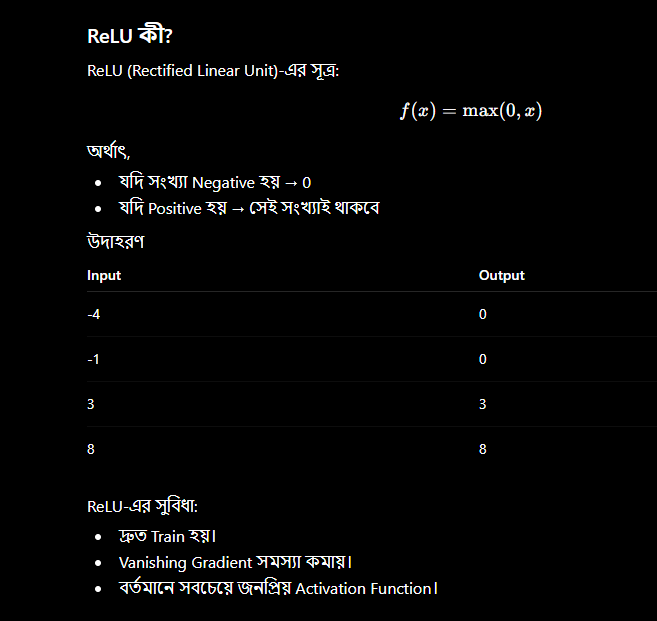

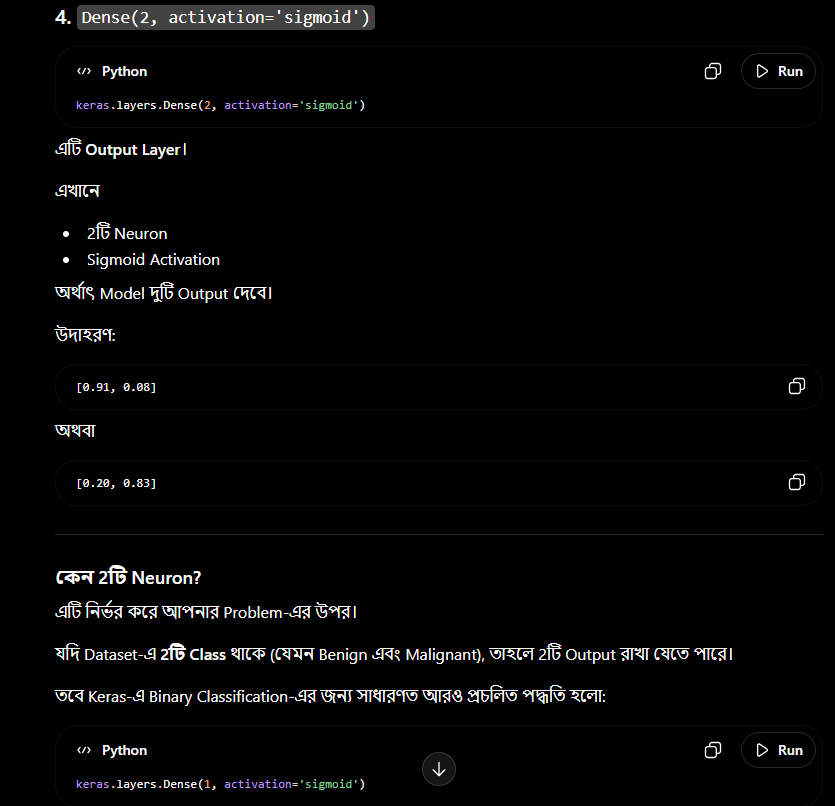

In [ ]:
# compiling the Neural Network

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Neural Network Compile করা

Neural Network তৈরি করার পর সেটিকে Training-এর জন্য প্রস্তুত করতে model.compile() ব্যবহার করা হয়। এই ধাপে Keras-কে জানানো হয়—

কোন Optimizer ব্যবহার করে Model-এর Weight Update করবে।

কোন Loss Function ব্যবহার করে ভুল (Error) পরিমাপ করবে।

কোন Metric ব্যবহার করে Model-এর Performance মূল্যায়ন করবে।

# Compiling the Neural Network

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

১. optimizer='adam'

Adam (Adaptive Moment Estimation) একটি জনপ্রিয় Optimizer।

এর কাজ হলো Training-এর সময় Model-এর Weight এবং Bias পরিবর্তন করে Prediction-এর ভুল কমানো।

Adam Optimizer-এর সুবিধা:

দ্রুত Model Train করতে সাহায্য করে।

স্বয়ংক্রিয়ভাবে Learning Rate সমন্বয় করে।

অধিকাংশ Deep Learning সমস্যায় ভালো ফলাফল দেয়।

২. loss='sparse_categorical_crossentropy'

Loss Function Model-এর Prediction এবং প্রকৃত (Actual) Output-এর মধ্যে কতটা পার্থক্য রয়েছে তা নির্ণয় করে।

sparse_categorical_crossentropy ব্যবহার করা হয় যখন:

সমস্যা Multi-Class Classification হয়।

Target Label Integer আকারে থাকে (যেমন: 0, 1, 2, 3 ইত্যাদি)।

Label One-Hot Encoded নয়।

Training-এর সময় Model-এর লক্ষ্য থাকে এই Loss-এর মান যত সম্ভব কমানো।

৩. metrics=['accuracy']

Accuracy হলো Model-এর Performance পরিমাপ করার একটি Metric।

এটি দেখায় Model কত শতাংশ Data সঠিকভাবে Predict করেছে।

উদাহরণ:

মোট Data = 1000

সঠিক Prediction = 950

তাহলে,

Accuracy = 95%

Accuracy শুধুমাত্র Model-এর ফলাফল মূল্যায়ন করে; এটি Weight Update করে না।

In [ ]:
# training the Meural Network

history = model.fit(X_train_std, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.1760 - loss: 1.4051 - val_accuracy: 0.2609 - val_loss: 1.0563
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3399 - loss: 0.9283 - val_accuracy: 0.6087 - val_loss: 0.6900
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6333 - loss: 0.6382 - val_accuracy: 0.7826 - val_loss: 0.4706
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8337 - loss: 0.4686 - val_accuracy: 0.8696 - val_loss: 0.3450
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8826 - loss: 0.3681 - val_accuracy: 0.9565 - val_loss: 0.2736
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9071 - loss: 0.3050 - val_accuracy: 0.9565 - val_loss: 0.2302
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9267 - loss: 0.2620 - val_accuracy: 0.9565 - val_loss: 0.2015
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9315 - loss: 0.2309 - val_accuracy: 0.9565 - val_l

validation_split=0.1

Training Data-এর 10% অংশ Validation Data হিসেবে আলাদা করা হয়।

অর্থাৎ,

90% Data → Model Train করার জন্য।

10% Data → Model-এর Performance যাচাই করার জন্য।

Validation Data Training-এ ব্যবহার হয় না। এটি শুধু প্রতিটি Epoch শেষে Model কতটা ভালো শিখছে তা পরীক্ষা করে।

উদাহরণ:

যদি মোট Training Data = 10,000

তাহলে,

Training Data = 9,000

Validation Data = 1,000

#############################################################

epochs=10

Epoch বলতে বোঝায় পুরো Training Dataset-এর উপর Model একবার সম্পূর্ণ Training করা।

এখানে,

epochs=10

মানে Model পুরো Training Dataset-এর উপর 10 বার Training করবে।

প্রতিটি Epoch শেষে সাধারণত নিচের তথ্য দেখা যায়:

Training Loss

Training Accuracy

Validation Loss

Validation Accuracy

যদি Accuracy ধীরে ধীরে বাড়ে এবং Loss কমে, তাহলে বোঝা যায় Model সঠিকভাবে শিখছে।

Visualizing accuracy and **loss**

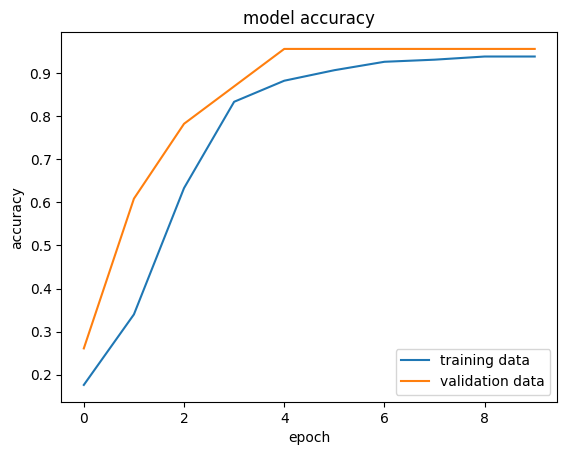

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'], loc = 'lower right')

plt.plot(history.history['accuracy'])

এই লাইনের মাধ্যমে Training Accuracy-এর Graph আঁকা হয়।

history.history['accuracy']-এ প্রতিটি Epoch-এর Training Accuracy সংরক্ষিত থাকে।

উদাহরণ:

Epoch 1 → 85%

Epoch 2 → 89%

Epoch 3 → 92%

...

Epoch 10 → 98%

এগুলোকে Line Graph হিসেবে দেখানো হয়।

#########################################################

plt.plot(history.history['val_accuracy'])

এই লাইনের মাধ্যমে Validation Accuracy-এর Graph আঁকা হয়।

Validation Accuracy দেখায় Model নতুন (Validation) Data-এর উপর কতটা ভালো কাজ করছে।

উদাহরণ:

Epoch 1 → 84%

Epoch 2 → 87%

Epoch 3 → 90%

...

Epoch 10 → 95%

##############################################

plt.legend(['Training Data', 'Validation Data'], loc='lower right')

Legend Graph-এর কোন লাইনটি কী বোঝায় তা দেখায়।

Training Data → Training Accuracy-এর Line

Validation Data → Validation Accuracy-এর Line

loc='lower right' অর্থ হলো Legend Graph-এর নিচের ডান পাশে প্রদর্শিত হবে।



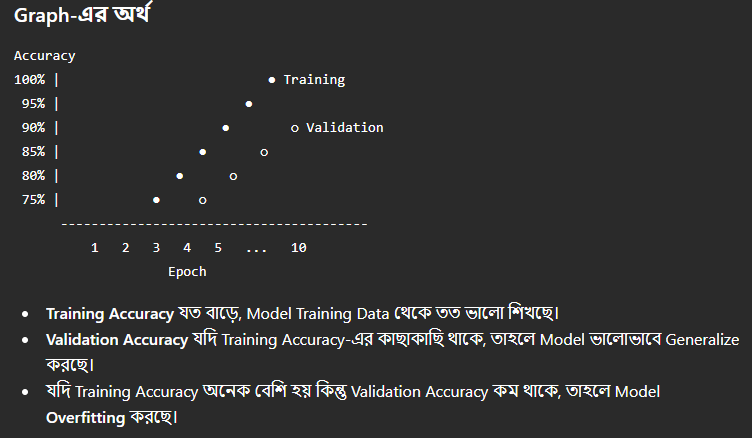

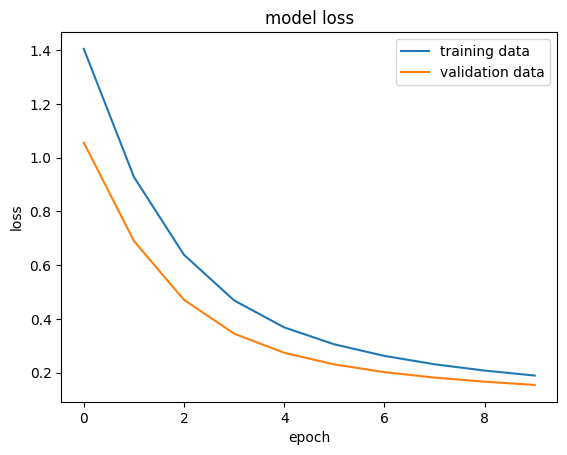

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'], loc = 'upper right')

plt.plot(history.history['loss'])

এই লাইনের মাধ্যমে Training Loss-এর Graph আঁকা হয়।

history.history['loss']-এ প্রতিটি Epoch-এর Training Loss সংরক্ষিত থাকে।

উদাহরণ:

Epoch 1 → 0.65

Epoch 2 → 0.48

Epoch 3 → 0.35

...

Epoch 10 → 0.08

যদি Training-এর সাথে সাথে Loss কমতে থাকে, তাহলে বোঝা যায় Model ধীরে ধীরে আরও ভালোভাবে শিখছে।

#################################################

plt.plot(history.history['val_loss'])

এই লাইনের মাধ্যমে Validation Loss-এর Graph আঁকা হয়।

Validation Loss দেখায় নতুন (Validation) Data-এর উপর Model কতটা ভুল করছে।

উদাহরণ:

Epoch 1 → 0.68

Epoch 2 → 0.52

Epoch 3 → 0.40

...

Epoch 10 → 0.12

Validation Loss কম হলে বোঝা যায় Model নতুন Data-এর উপরও ভালো Performance দিচ্ছে।


Accuracy of the model on test **data**

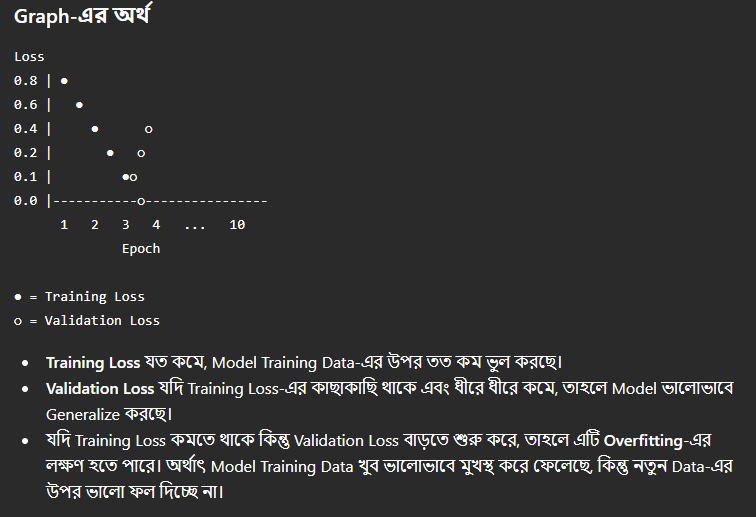

In [ ]:
loss, accuracy = model.evaluate(X_test_std, Y_test)
print(accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9561 - loss: 0.1764
0.9561403393745422


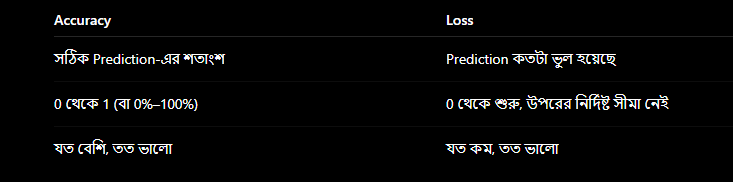

In [ ]:
print(X_test_std.shape)
print(X_test_std[0])

(114, 30)
[-0.04462793 -1.41612656 -0.05903514 -0.16234067  2.0202457  -0.11323672
  0.18500609  0.47102419  0.63336386  0.26335737  0.53209124  2.62763999
  0.62351167  0.11405261  1.01246781  0.41126289  0.63848593  2.88971815
 -0.41675911  0.74270853 -0.32983699 -1.67435595 -0.36854552 -0.38767294
  0.32655007 -0.74858917 -0.54689089 -0.18278004 -1.23064515 -0.6268286 ]


In [ ]:
Y_pred = model.predict(X_test_std)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


Y_pred

Y_pred-এ Model-এর Prediction সংরক্ষিত থাকে।

যেহেতু Output Layer-এ

keras.layers.Dense(2, activation='sigmoid')

ব্যবহার করা হয়েছে, তাই প্রতিটি Sample-এর জন্য দুটি Probability পাওয়া যাবে।

উদাহরণ:

[
 [0.98, 0.02],

 [0.15, 0.87],

 [0.76, 0.24]

]

প্রথম Sample-এর জন্য:

Class 0 → 0.98

Class 1 → 0.02

দ্বিতীয় Sample-এর জন্য:

Class 0 → 0.15

Class 1 → 0.87

Prediction-এর Output দেখা

print(Y_pred)

Output:

[
 [0.98 0.02]

 [0.15 0.87]

 [0.76 0.24]

 ...

]

এগুলো সরাসরি Class নয়, বরং প্রতিটি Class-এর জন্য Model-এর Confidence (Probability বা Score)।

In [ ]:
print(Y_pred.shape)
print(Y_pred[0])

(114, 2)
[0.4499335 0.5875711]


In [ ]:
print(X_test_std)

[[-0.04462793 -1.41612656 -0.05903514 ... -0.18278004 -1.23064515
  -0.6268286 ]
 [ 0.24583601 -0.06219797  0.21802678 ...  0.54129749  0.11047691
   0.0483572 ]
 [-1.26115925 -0.29051645 -1.26499659 ... -1.35138617  0.269338
  -0.28231213]
 ...
 [ 0.72709489  0.45836817  0.75277276 ...  1.46701686  1.19909344
   0.65319961]
 [ 0.25437907  1.33054477  0.15659489 ... -1.29043534 -2.22561725
  -1.59557344]
 [ 0.84100232 -0.06676434  0.8929529  ...  2.15137705  0.35629355
   0.37459546]]


In [ ]:
print(Y_pred)

[[0.4499335  0.5875711 ]
 [0.38365775 0.5222976 ]
 [0.10071685 0.6683537 ]
 [0.99722356 0.03708772]
 [0.44650295 0.4716154 ]
 [0.94342077 0.06710094]
 [0.41416106 0.6319643 ]
 [0.06107312 0.7457152 ]
 [0.15190274 0.561408  ]
 [0.10884633 0.6969518 ]
 [0.27001932 0.5094242 ]
 [0.09636309 0.6365398 ]
 [0.2972479  0.50286496]
 [0.17503974 0.5486595 ]
 [0.1349812  0.5793492 ]
 [0.8815455  0.11634038]
 [0.06856812 0.7320054 ]
 [0.16818924 0.8267547 ]
 [0.20219922 0.49754483]
 [0.94426626 0.15515538]
 [0.90886015 0.96264035]
 [0.10190347 0.7400612 ]
 [0.11710756 0.7648816 ]
 [0.04184978 0.6742913 ]
 [0.19639577 0.5362156 ]
 [0.772947   0.12016612]
 [0.14950989 0.70008576]
 [0.25512263 0.42230108]
 [0.68105346 0.07800916]
 [0.787509   0.07875958]
 [0.19893682 0.75145507]
 [0.19291706 0.4792179 ]
 [0.15320194 0.6689438 ]
 [0.9245096  0.00503621]
 [0.87297297 0.12329668]
 [0.18561548 0.71178174]
 [0.07048684 0.85311276]
 [0.16920285 0.6345898 ]
 [0.05630458 0.7464517 ]
 [0.11310016 0.5910164 ]


model.predict() gives the prediction probability of each class for that data **point**

In [ ]:
#  argmax function

my_list = [0.25, 0.56]

index_of_max_value = np.argmax(my_list)
print(my_list)
print(index_of_max_value)

[0.25, 0.56]
1


In [ ]:
# converting the prediction probability to class labels

Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels)

[np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1)

**Building the predictive system**

In [ ]:
input_data = (11.76,21.6,74.72,427.9,0.08637,0.04966,0.01657,0.01115,0.1495,0.05888,0.4062,1.21,2.635,28.47,0.005857,0.009758,0.01168,0.007445,0.02406,0.001769,12.98,25.72,82.98,516.5,0.1085,0.08615,0.05523,0.03715,0.2433,0.06563)

# change the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array as we are predicting for one data point
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardizing the input data
input_data_std = scaler.transform(input_data_reshaped)

prediction = model.predict(input_data_std)
print(prediction)

prediction_label = [np.argmax(prediction)]
print(prediction_label)

if(prediction_label[0] == 0):
  print('The tumor is Malignant')

else:
  print('The tumor is Benign')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[[0.09566025 0.73408115]]
[np.int64(1)]
The tumor is Benign


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
